# Benchmark a Knill quantum-error-correction cycle

Knill QEC teleports the logical state from one code block to another.
The Bell-basis measurements used for teleportation also provide the syndrome information needed to update the Pauli frame.

The price is a fault-tolerantly prepared encoded Bell pair.
This notebook assembles the full Steane-code circuit so the qubit bookkeeping, detectors, logical observables, post-selection flags, and final benchmark remain visible.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import sinter
import stim

from qldpc import circuits, codes, decoders
from qldpc.objects import Pauli

In [3]:
def plot_error_and_discard_rates(
    error_rates: npt.NDArray[np.float64],
    logical_error_rates: npt.NDArray[np.float64],
    logical_error_low: npt.NDArray[np.float64],
    logical_error_high: npt.NDArray[np.float64],
    discard_rates: npt.NDArray[np.float64],
    discard_low: npt.NDArray[np.float64],
    discard_high: npt.NDArray[np.float64],
):
    figure, axes = plt.subplots(1, 2, sharex=True, figsize=(7.5, 3.2))

    positive = logical_error_rates > 0
    axes[0].errorbar(
        error_rates[positive],
        logical_error_rates[positive],
        yerr=np.vstack(
            (
                logical_error_rates[positive] - logical_error_low[positive],
                logical_error_high[positive] - logical_error_rates[positive],
            )
        ),
        marker="o",
        linestyle="-",
        capsize=3,
        label="Knill QEC",
    )
    zero = ~positive
    axes[0].scatter(
        error_rates[zero],
        logical_error_high[zero],
        marker="v",
        facecolors="none",
        edgecolors="C0",
        label="zero failures (upper likelihood bound)",
    )
    axes[0].plot(
        [error_rates.min(), error_rates.max()],
        [error_rates.min(), error_rates.max()],
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axes[0].set_ylabel("estimated logical error rate")

    axes[1].errorbar(
        error_rates,
        discard_rates,
        yerr=np.vstack((discard_rates - discard_low, discard_high - discard_rates)),
        marker="s",
        linestyle="--",
        capsize=3,
        label="flag discard",
    )
    axes[1].set_ylabel("estimated discard rate")

    for axis in axes:
        axis.set_xlabel("physical error rate per operation")
        axis.loglog()
        axis.grid(which="both", alpha=0.3)
        axis.legend(loc="best")
    figure.tight_layout()
    return figure, axes

## Encoded ancilla blocks

The flagged circuit prepares logical zero.
Applying transversal Hadamards to its seven data qubits gives the matching logical-plus preparation.
The eighth qubit is a flag and is not transformed.


In [4]:
code = codes.SteaneCode()

# |0> state prep circuit
zero_prep_circuit = stim.Circuit("""
    # non-fault-tolerant state preparation
    H 0 2 4
    CX 0 3 2 1 4 5
    CX 0 1 2 6 4 3
    CX 2 5 3 6
    # flag errors in a logical Z representative
    H 7
    CZ 7 1 7 3 7 5
    MX 7
    DETECTOR rec[-1]  # post-selection flag
""")

# |+> state prep circuit
plus_prep_circuit = zero_prep_circuit.copy()
plus_prep_circuit.append("H", range(len(code)))

## Allocate qubits and records

Block 0 holds the input, blocks 1 and 2 form the encoded Bell pair, and ideal reference qubits let the simulation track both X- and Z-type logical observables.
`MeasurementRecord` and `DetectorRecord` keep later annotations tied to the measurements that define them.


In [5]:
# Identify the qubits used by each code block.
# The method circuits.QubitIDs.from_code(code) will automatically allocate len(code) data qubits
# and len(code.matrix) "check" qubits (one for each stabilizer).  You can additionally pass
# QubitIDs.from_code(code, num_references=...) to allocate ideal reference qubits.
qubit_ids_0 = circuits.QubitIDs.from_code(code, num_references=code.dimension)
qubit_ids_1 = qubit_ids_0.shifted(qubit_ids_0.max() + 1)
qubit_ids_2 = qubit_ids_1.shifted(qubit_ids_1.max() + 1)

# records to keep track of measurements and detectors in the circuit we build
meas_record = circuits.MeasurementRecord()
det_record = circuits.DetectorRecord()

## Assemble the teleportation circuit

The ideal references are an analysis device.
They make a combined-basis benchmark possible without claiming that noiseless ancillas are available in hardware.

After the Bell-basis measurement, stabilizer parities become detectors and logical parities become Stim observables.
The final noiseless readout closes the detector boundaries on block 2.


In [6]:
# initialize empty circuit
circuit = stim.Circuit()

# prepare a logical Bell-pair state noiselessly on code block 0, and annotate its observables
circuit += circuits.get_logical_bell_prep(
    code,
    data_qubits=qubit_ids_0.data,
    reference_qubits=qubit_ids_0.reference,
)
circuit += circuits.get_observables(code, qubit_ids_0.data)

# prepare blocks 1 and 2 in a logical Bell state, and record flag detectors for post-selection
circuit += circuits.with_remapped_qubits(plus_prep_circuit, qubit_ids_1.all_qubits)
circuit += circuits.with_remapped_qubits(zero_prep_circuit, qubit_ids_2.all_qubits)
for cc, tt in zip(qubit_ids_1.data, qubit_ids_2.data):
    circuit.append("CX", [cc, tt])
det_record.append({"flags": range(circuit.num_detectors)})

# measure blocks 0 and 1 in the Bell basis, keeping a record of the measurements
for cc, tt in zip(qubit_ids_0.data, qubit_ids_1.data):
    circuit.append("CX", [cc, tt])
circuit.append("MX", qubit_ids_0.data)
circuit.append("MZ", qubit_ids_1.data)
meas_record.append(
    {qubit: meas_index for meas_index, qubit in enumerate(qubit_ids_0.data + qubit_ids_1.data)}
)

# Annotate stabilizers (detectors) supported on the measurements of blocks 0 and 1,
# as well as the observables flipped by logical corrections from these measurement outcomes.
for data_qubits, basis in [
    (qubit_ids_0.data, Pauli.X),
    (qubit_ids_1.data, Pauli.Z),
]:
    # stabilizers
    for op_vec in code.get_stabilizer_ops(basis):
        support = [data_qubits[qubit] for qubit in range(len(code)) if op_vec[qubit]]
        target_recs = [meas_record.get_target_rec(qubit) for qubit in support]
        circuit.append("DETECTOR", target_recs)
    # observables
    for index, op_vec in enumerate(code.get_logical_ops(basis)):
        support = [data_qubits[qubit] for qubit in range(len(code)) if op_vec[qubit]]
        target_recs = [meas_record.get_target_rec(qubit) for qubit in support]
        # X-type observables are numbered from 0 to code.dimension-1, while
        # Z-type observables are numbered from code.dimension to 2*code.dimension-1.
        observable_index = index + code.dimension * int(basis)
        circuit.append("OBSERVABLE_INCLUDE", target_recs, [observable_index])

# append final (noiseless) stabilizer and observable readout
circuit += circuits.as_noiseless_circuit(
    circuits.get_pauli_product_measurements(code.get_stabilizer_ops(), qubit_ids_2.data)
)
for index in range(len(code.get_stabilizer_ops())):
    circuit.append("DETECTOR", [stim.target_rec(-index - 1)])
circuit += circuits.get_observables(code, qubit_ids_2.data)

## Add noise, decode, and post-select

The state-preparation flags recorded above define the discarded shots.
The logical error rate is conditioned on the shots that survive, so the logical and discard rates must be reported together.

The asymmetric bars contain rates whose binomial likelihood is within a factor of 1,000 of the best fit.
The printed counts keep low-statistics points visible rather than letting a smooth line hide zero or only a few observed failures.
A zero-failure point cannot sit on the log axis, so the hollow downward triangle is placed at that point's upper likelihood bound.


In [7]:
error_rates = np.logspace(-4, -2, 5)
sinter_decoder = decoders.SinterDecoder(with_lookup=True, max_weight=3, add_erasure_bit=True)

logical_error_rates = np.empty_like(error_rates)
logical_error_low = np.empty_like(error_rates)
logical_error_high = np.empty_like(error_rates)
discard_rates = np.empty_like(error_rates)
discard_low = np.empty_like(error_rates)
discard_high = np.empty_like(error_rates)
num_samples = 100_000

for index, error_rate in enumerate(error_rates):
    noise_model = circuits.DepolarizingNoiseModel(error_rate)
    noisy_circuit = noise_model.noisy_circuit(circuit)
    logical_error_rates[index], discard_rates[index] = circuits.get_logical_error_and_discard_rate(
        noisy_circuit,
        sinter_decoder,
        num_samples=num_samples,
        post_select=det_record.get_events("flags"),
    )

    num_discards = round(discard_rates[index] * num_samples)
    num_kept = num_samples - num_discards
    num_failures = round(logical_error_rates[index] * num_kept)
    logical_fit = sinter.fit_binomial(
        num_shots=num_kept,
        num_hits=num_failures,
        max_likelihood_factor=1_000,
    )
    discard_fit = sinter.fit_binomial(
        num_shots=num_samples,
        num_hits=num_discards,
        max_likelihood_factor=1_000,
    )
    logical_error_low[index] = logical_fit.low
    logical_error_high[index] = logical_fit.high
    discard_low[index] = discard_fit.low
    discard_high[index] = discard_fit.high
    print(
        f"p={error_rate:.4g}: failures={num_failures}/{num_kept} kept, "
        f"discards={num_discards}/{num_samples}"
    )

p=0.0001: failures=0/99846 kept, discards=154/100000


p=0.0003162: failures=3/99520 kept, discards=480/100000


p=0.001: failures=32/98530 kept, discards=1470/100000


p=0.003162: failures=275/95427 kept, discards=4573/100000


p=0.01: failures=2321/86407 kept, discards=13593/100000


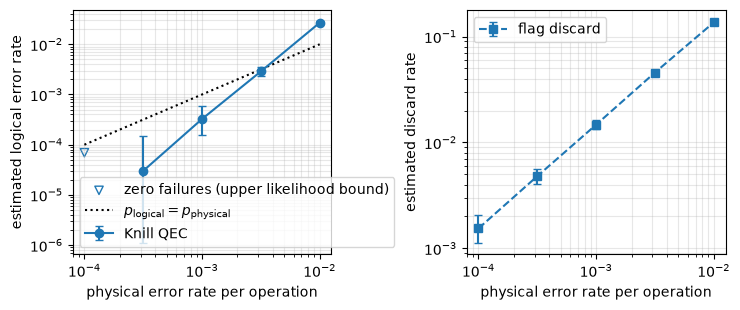

In [8]:
plot_error_and_discard_rates(
    error_rates,
    logical_error_rates,
    logical_error_low,
    logical_error_high,
    discard_rates,
    discard_low,
    discard_high,
)
plt.show()

The falling or rising shape of five sampled points does not by itself establish a threshold.
This benchmark is most useful as copyable circuit assembly and as a regression-sized comparison of noise, decoder, and post-selection choices.
